<a href="https://colab.research.google.com/github/carlg3/progetto_detr/blob/main/detr_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine‑tuning DETR (facebookresearch/detr) su Hard‑Hat (Kaggle)

Notebook che: clona il repo DETR al commit richiesto, converte il dataset Hard‑Hat in COCO, esegue fine‑tuning usando gli script del repo, valuta con pycocotools e visualizza risultati e grafici. Esegui le celle in ordine. Se sei in Colab carica `kaggle.json` in `/content` prima di scaricare il dataset.

In [1]:
# 1) Clona il repo al commit richiesto e installa dipendenze minime
import os, sys, textwrap
REPO_URL = 'https://github.com/facebookresearch/detr.git'
COMMIT = '29901c51d7fe8712168b8d0d64351170bc0f83e0'
if not os.path.exists('detr'):
    !git clone {REPO_URL} detr
    %cd detr
    !git fetch --all --tags
    !git checkout {COMMIT}
    %cd ..
else:
    print('detr/ already exists; skipping clone')

# install needed Python packages
!pip install -q pycocotools matplotlib pandas opencv-python tqdm kaggle

os.environ['DETR_DIR'] = os.path.join(os.getcwd(), 'detr')
sys.path.insert(0, os.environ['DETR_DIR'])
print('DETR repo added to PYTHONPATH:', os.environ['DETR_DIR'])

Cloning into 'detr'...
remote: Enumerating objects: 265, done.
remote: Total 265 (delta 0), reused 0 (delta 0), pack-reused 265 (from 1)
Receiving objects: 100% (265/265), 21.19 MiB | 17.26 MiB/s, done.
Resolving deltas: 100% (120/120), done.
/content/detr
Note: switching to '29901c51d7fe8712168b8d0d64351170bc0f83e0'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 29901c5 Delete .circleci directory
/content
DETR repo added to PYTHONPATH: /content/detr


### 2) (Opzionale) Scarica il dataset Hard‑Hat da Kaggle

Se sei su Colab, carica `kaggle.json` in `/content` (Files panel) prima di eseguire la cella seguente. Se hai già il dataset scaricato salta questa cella e imposta `RAW_DATA_DIR` nella cella di conversione.

In [2]:
!mkdir -p ~/.kaggle && echo KGAT_f78d2448f937556577c4ae93fed40471 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [3]:
# Scarica e scompatta il dataset (richiede CLI kaggle configurata)
RAW_DATA_DIR = 'data/hard-hat-dataset'
if not os.path.exists('data'):
    os.makedirs('data', exist_ok=True)

kaggle_json = '/content/kaggle.json'
if os.path.exists(kaggle_json):
    !mkdir -p ~/.kaggle
    !cp {kaggle_json} ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    print('kaggle.json copied to ~/.kaggle')
else:
    print('kaggle.json not found at /content/kaggle.json; if you already have the dataset locally skip download')

if not os.path.exists(RAW_DATA_DIR):
    !kaggle datasets download -d andrewmvd/hard-hat-detection -p data --unzip
    # dataset unzips into a folder; move/rename to RAW_DATA_DIR if needed
    # the downloaded zip from this dataset contains a folder named 'Hard-Hat-Detection'
    !ls -lah data | sed -n '1,120p'
else:
    print('Raw dataset dir exists:', RAW_DATA_DIR)


kaggle.json not found at /content/kaggle.json; if you already have the dataset locally skip download
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection
License(s): CC0-1.0
100% 1.22G/1.22G [01:18<00:00, 16.7MB/s]

total 496K
drwxr-xr-x 4 root root 4.0K Sep 16 20:29 .
drwxr-xr-x 1 root root 4.0K Sep 16 20:27 ..
drwxr-xr-x 2 root root 248K Sep 16 20:29 annotations
drwxr-xr-x 2 root root 240K Sep 16 20:29 images


### 3) Conversione Hard‑Hat -> COCO (train/val split) e copia immagini
La funzione sotto crea la struttura `hardhat_coco/train2017`, `hardhat_coco/val2017` e i file `instances_train2017.json` / `instances_val2017.json`.

```
/content/hardhat_coco/
├── train2017/
├── val2017/
└── annotations/
    ├── instances_train2017.json
    └── instances_val2017.json
```

In [4]:
# @title
import json
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

from PIL import Image
import pandas as pd


RAW = Path("/content/data")
OUT = Path("/content/hardhat_coco")

EXPECTED_CLASSES = ["Helmet", "Person", "Head"]
CLASS_MAP = {
    "helmet": "Helmet",
    "person": "Person",
    "head": "Head",
}
CAT_MAP = {
    class_name: class_id
    for class_id, class_name in enumerate(EXPECTED_CLASSES, start=1)
}


def reset_output_directory(output_dir):
    for directory in (
        output_dir / "train2017",
        output_dir / "val2017",
        output_dir / "annotations",
    ):
        if directory.exists():
            shutil.rmtree(directory)

    output_dir.mkdir(parents=True, exist_ok=True)


def normalize_class_name(raw_name):
    normalized_name = str(raw_name).strip().lower()

    if normalized_name not in CLASS_MAP:
        raise ValueError(
            f"Classe non riconosciuta: {raw_name!r}. "
            f"Classi consentite: {list(CLASS_MAP.values())}"
        )

    return CLASS_MAP[normalized_name]


def parse_xml_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename_node = root.find("filename")

    if filename_node is None or not filename_node.text:
        raise ValueError(f"Filename mancante in {xml_file}")

    filename = filename_node.text.strip()
    records = []

    for obj in root.findall("object"):
        name_node = obj.find("name")
        bbox_node = obj.find("bndbox")

        if name_node is None or bbox_node is None:
            continue

        class_name = normalize_class_name(name_node.text)

        xmin = int(float(bbox_node.find("xmin").text))
        ymin = int(float(bbox_node.find("ymin").text))
        xmax = int(float(bbox_node.find("xmax").text))
        ymax = int(float(bbox_node.find("ymax").text))

        if xmax <= xmin or ymax <= ymin:
            continue

        records.append({
            "filename": filename,
            "class": class_name,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
        })

    return records


def find_image(raw_dir, filename):
    candidates = [
        raw_dir / filename,
        raw_dir / "images" / filename,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    matches = list(raw_dir.rglob(Path(filename).name))
    return matches[0] if matches else None


def split_images(filenames, validation_ratio=0.15, seed=42):
    filenames = list(sorted(filenames))

    random.seed(seed)
    random.shuffle(filenames)

    validation_size = max(1, int(len(filenames) * validation_ratio))

    validation_filenames = set(filenames[:validation_size])
    training_filenames = set(filenames[validation_size:])

    return training_filenames, validation_filenames


def copy_split_images(
    filenames,
    training_filenames,
    raw_dir,
    train_dir,
    val_dir,
):
    copied_train = set()
    copied_val = set()

    for filename in filenames:
        source = find_image(raw_dir, filename)

        if source is None:
            print(f"Immagine non trovata: {filename}")
            continue

        if filename in training_filenames:
            destination = train_dir / Path(filename).name
            copied_train.add(filename)
        else:
            destination = val_dir / Path(filename).name
            copied_val.add(filename)

        shutil.copy2(source, destination)

    return copied_train, copied_val


def build_coco_from_dataframe(dataframe, image_dir, output_json):
    images = {}
    annotations = []
    annotation_id = 1

    for _, row in dataframe.iterrows():
        filename = str(row["filename"])
        image_path = image_dir / Path(filename).name

        if not image_path.exists():
            continue

        if filename not in images:
            width, height = Image.open(image_path).size

            images[filename] = {
                "id": len(images) + 1,
                "file_name": image_path.name,
                "width": width,
                "height": height,
            }

        image_id = images[filename]["id"]

        x_min = float(row["xmin"])
        y_min = float(row["ymin"])
        x_max = float(row["xmax"])
        y_max = float(row["ymax"])

        box_width = x_max - x_min
        box_height = y_max - y_min
        class_name = str(row["class"]).strip()

        if class_name not in CAT_MAP:
            raise ValueError(
                f"Classe non presente nel mapping: {class_name!r}"
            )

        annotations.append({
            "id": annotation_id,
            "image_id": image_id,
            "category_id": CAT_MAP[class_name],
            "bbox": [x_min, y_min, box_width, box_height],
            "area": box_width * box_height,
            "iscrowd": 0,
        })

        annotation_id += 1

    coco_data = {
        "images": list(images.values()),
        "annotations": annotations,
        "categories": [
            {
                "id": category_id,
                "name": class_name,
            }
            for class_name, category_id in CAT_MAP.items()
        ],
    }

    output_json.parent.mkdir(parents=True, exist_ok=True)

    with output_json.open("w") as file:
        json.dump(coco_data, file, indent=2)

    print(
        f"{output_json}: "
        f"{len(images)} immagini, "
        f"{len(annotations)} annotazioni"
    )


def prepare_coco_dataset(
    raw_dir,
    output_dir,
    validation_ratio=0.15,
    seed=42,
):
    annotations_dir = raw_dir / "annotations"

    if not annotations_dir.exists():
        raise FileNotFoundError(
            f"Directory annotazioni non trovata: {annotations_dir}"
        )

    xml_files = sorted(annotations_dir.glob("*.xml"))

    if not xml_files:
        raise FileNotFoundError(
            f"Nessun file XML trovato in {annotations_dir}"
        )

    reset_output_directory(output_dir)

    all_annotations = []

    for xml_file in xml_files:
        all_annotations.extend(parse_xml_annotation(xml_file))

    dataframe = pd.DataFrame(all_annotations)

    if dataframe.empty:
        raise ValueError("Nessuna annotazione valida trovata.")

    found_classes = sorted(dataframe["class"].unique())
    expected_classes = sorted(EXPECTED_CLASSES)

    print("Classi trovate dopo la normalizzazione:", found_classes)
    print("Numero classi:", len(found_classes))
    print("\nAnnotazioni per classe:")
    print(dataframe["class"].value_counts())

    if found_classes != expected_classes:
        raise ValueError(
            f"Le classi trovate {found_classes} "
            f"non corrispondono alle classi attese {expected_classes}"
        )

    filenames = sorted(dataframe["filename"].unique())
    train_filenames, val_filenames = split_images(
        filenames,
        validation_ratio=validation_ratio,
        seed=seed,
    )

    train_dir = output_dir / "train2017"
    val_dir = output_dir / "val2017"
    coco_annotations_dir = output_dir / "annotations"

    train_dir.mkdir(parents=True, exist_ok=True)
    val_dir.mkdir(parents=True, exist_ok=True)
    coco_annotations_dir.mkdir(parents=True, exist_ok=True)

    copied_train, copied_val = copy_split_images(
        filenames=filenames,
        training_filenames=train_filenames,
        raw_dir=raw_dir,
        train_dir=train_dir,
        val_dir=val_dir,
    )

    train_dataframe = dataframe[
        dataframe["filename"].isin(copied_train)
    ]

    val_dataframe = dataframe[
        dataframe["filename"].isin(copied_val)
    ]

    build_coco_from_dataframe(
        train_dataframe,
        train_dir,
        coco_annotations_dir / "instances_train2017.json",
    )

    build_coco_from_dataframe(
        val_dataframe,
        val_dir,
        coco_annotations_dir / "instances_val2017.json",
    )

    print("\nDataset COCO creato correttamente.")
    print("Directory:", output_dir)
    print("Immagini train:", len(copied_train))
    print("Immagini val:", len(copied_val))
    print("Mapping classi:", CAT_MAP)


prepare_coco_dataset(
    raw_dir=RAW,
    output_dir=OUT,
    validation_ratio=0.15,
    seed=42,
)

Classi trovate dopo la normalizzazione: ['Head', 'Helmet', 'Person']
Numero classi: 3

Annotazioni per classe:
class
Helmet    18966
Head       5785
Person      751
Name: count, dtype: int64
/content/hardhat_coco/annotations/instances_train2017.json: 4250 immagini, 21569 annotazioni
/content/hardhat_coco/annotations/instances_val2017.json: 750 immagini, 3933 annotazioni

Dataset COCO creato correttamente.
Directory: /content/hardhat_coco
Immagini train: 4250
Immagini val: 750
Mapping classi: {'Helmet': 1, 'Person': 2, 'Head': 3}


### 4) Scarica pesi pretrained ufficiali DETR (opzionale ma raccomandato)
I pesi verranno posti nella cartella `detr/` per essere usati come `--resume`.

In [5]:
if not os.path.exists('detr/detr-r50-e632da11.pth'):
    !wget -q -O detr/detr-r50-e632da11.pth https://dl.fbaipublicfiles.com/detr/detr-r50-e632da11.pth
    print('downloaded pretrained weights')
else:
    print('pretrained weights already present')

downloaded pretrained weights


### 5) Fine‑tuning con gli script ufficiali
Esempio di comando che sfrutta `detr/main.py`. Aggiusta `--batch_size`, `--epochs` in base alla GPU disponibile. Qui usiamo `--dataset_file coco` e `--coco_path hardhat_coco`.

In [6]:
OUTPUT_DIR = 'output_hardhat'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# Comando di training (esegui per davvero; richiede GPU per essere pratico)
TRAIN_CMD = 'python detr/main.py --coco_path hardhat_coco --dataset_file coco --batch_size 2 --lr 1e-4 --lr_backbone 1e-5 --epochs 12 --device cuda --resume detr/detr-r50-e632da11.pth --output_dir {out}'
print('Se vuoi lanciare il training, esegui il comando seguente nella shell (o scommenta la riga sottostante per eseguirlo qui):')
print(TRAIN_CMD.format(out=OUTPUT_DIR))

Se vuoi lanciare il training, esegui il comando seguente nella shell (o scommenta la riga sottostante per eseguirlo qui):
python detr/main.py --coco_path hardhat_coco --dataset_file coco --batch_size 2 --lr 1e-4 --lr_backbone 1e-5 --epochs 12 --device cuda --resume detr/detr-r50-e632da11.pth --output_dir output_hardhat


### 6) Valutazione / inferenza su singola immagine usando il checkpoint salvato
Lo script qui sotto carica il checkpoint salvato dal training (o il pretrained) e fa inferenza su un'immagine di validazione, visualizzando bbox/classe/score.

In [ ]:
# @title
import torch, json, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from pathlib import Path
from detr.main import get_args_parser # Import get_args_parser
from models import build_model


def load_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location='cpu')
    return ckpt

def build_and_load_model_from_ckpt(ckpt_path, device='cpu'):

    ckpt = load_ckpt(ckpt_path)

    # Try to load args from checkpoint, if not present, use defaults
    args = ckpt.get('args', None)

    if args is None:
        print(f"Checkpoint '{ckpt_path}' does not contain 'args'. Using default DETR args and setting specific ones.")
        parser = get_args_parser()
        args = parser.parse_args([]) # Parse an empty list to get defaults

        # Override with necessary settings for our context/model
        args.backbone = 'resnet50'
        args.hidden_dim = 256
        args.num_queries = 100
        args.masks = False
        args.aux_loss = False # Default in DETR (and likely in pretrained checkpoint)
        args.dilation = False # Default in DETR
        args.train_backbone = True # Default in DETR
        args.lr_backbone = 1e-5 # From TRAIN_CMD

        # Essential for build_model to determine num_classes (91 for coco)
        args.dataset_file = 'coco'

        # Set device as it's used by torch.device(args.device) in detr.build
        args.device = device

    model, criterion, postprocessors = build_model(args)
    model.load_state_dict(ckpt['model'])
    model.to(device).eval()
    return model, postprocessors

def preprocess_pil(img:Image.Image):
    arr = np.array(img).astype(np.float32)/255.0
    t = torch.from_numpy(arr).permute(2,0,1)
    return t

def visualize_preds(img_path, boxes, labels, scores, class_names, score_thr=0.3):
    img = cv2.imread(img_path)[:,:,::-1]
    plt.figure(figsize=(12,8)); plt.imshow(img); ax = plt.gca()
    for b,l,s in zip(boxes, labels, scores):
        if s < score_thr: continue
        x1,y1,x2,y2 = map(int,b)
        ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2))
        ax.text(x1, y1-2, f"{class_names.get(int(l),'?')}: {s:.2f}", color='white', bbox=dict(facecolor='red', alpha=0.6))
    plt.axis('off'); plt.show()

# pick a checkpoint (prefer the trained checkpoint if present)
ckpt_candidates = sorted(glob.glob(OUTPUT_DIR + '/checkpoint*.pth') + glob.glob(OUTPUT_DIR + '/checkpoint.pth'))
if len(ckpt_candidates) == 0:
    ckpt_candidates = ['detr/detr-r50-e632da11.pth']
ckpt_path = ckpt_candidates[-1]
print('Using checkpoint:', ckpt_path)

'''
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model, postprocessors = build_and_load_model_from_ckpt(ckpt_path, device=device)

    # pick a val image
    val_images = sorted(glob.glob('hardhat_coco/val2017/*'))
    if not val_images:
        print('No val images found in hardhat_coco/val2017')
    else:
        img_path = val_images[0]
        img = Image.open(img_path).convert('RGB')
        inp = preprocess_pil(img).to(device)
        with torch.no_grad():
            # The model directly outputs a dictionary when a single input is provided in eval mode.
            # Removing [0] to correctly access the dictionary.
            out = model([inp])
        # try to robustly extract boxes/scores/labels
        if 'pred_boxes' in out:
            boxes = out['pred_boxes'].cpu().numpy()
        elif 'boxes' in out:
            boxes = out['boxes'].cpu().numpy()
        else:
            boxes = np.zeros((0,4))
        scores = out.get('scores', torch.zeros(len(boxes))).cpu().numpy()
        labels = out.get('labels', torch.zeros(len(boxes))).cpu().numpy()
        w,h = img.size
        if boxes.size and boxes.max() <= 1.01:
            cx = boxes[:,0]*w; cy = boxes[:,1]*h; bw = boxes[:,2]*w; bh = boxes[:,3]*h
            boxes = np.stack([cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2], axis=1)
        class_names = {1:'Helmet',2:'Person',3:'Head'}
        visualize_preds(img_path, boxes, labels, scores, class_names, score_thr=0.3)
'''

### 7) Valutazione mAP (pycocotools) sulla validation set
Il blocco seguente: esegue inferenza su tutte le immagini di `val2017`, salva i risultati in formato COCO results JSON, poi usa COCOeval per ottenere mAP e AP per classe e disegna un grafico a barre.

Checkpoint 'detr/detr-r50-e632da11.pth' does not contain 'args'. Using default DETR args and setting specific ones.
Analizzando le predizioni da: val_predictions.json
Generazione del file di predizioni...
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


inference val: 100%|██████████| 750/750 [00:27<00:00, 27.53it/s]


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.34s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.80s).
Accumulating evaluation results...
DONE (t=0.41s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.005
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

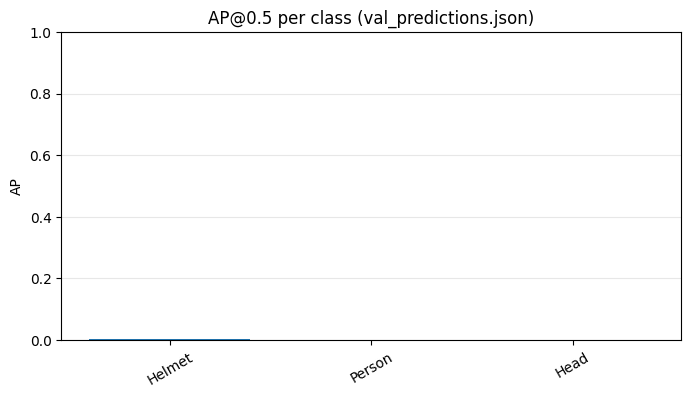

mAP@.5 (from COCOeval): 0.0007427001025254556


In [8]:
# @title
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import glob, os, json
import numpy as np
import tqdm
import matplotlib.pyplot as plt

def model_predict_all(model, postprocessors, device, images_dir, out_json='preds_val.json', score_thr=0.01):
    model.eval()
    preds = []
    img_files = sorted(glob.glob(os.path.join(images_dir, '*')))
    coco_gt = COCO('hardhat_coco/annotations/instances_val2017.json')
    # build mapping filename->image_id from GT
    fname2id = {img['file_name']: img['id'] for img in coco_gt.loadImgs(coco_gt.getImgIds())}
    for p in tqdm.tqdm(img_files, desc='inference val'):
        fn = os.path.basename(p)
        img = Image.open(p).convert('RGB')
        inp = torch.from_numpy(np.array(img).astype(np.float32)/255.0).permute(2,0,1).to(device)
        with torch.no_grad():
            out = model([inp])

        # Get original image size for postprocessing
        w, h = img.size
        target_sizes = torch.tensor([[h, w]]).to(device)
        # Process raw model output to get final predictions (boxes, scores, labels)
        # Correctly call the postprocessor from the dictionary
        processed_outputs = postprocessors['bbox'](out, target_sizes)[0] # [0] for single image batch

        # Extract boxes, scores, and labels from processed_outputs
        # boxes are already in xmin, ymin, xmax, ymax format and pixel coordinates
        boxes = processed_outputs['boxes'].cpu().numpy()
        scores = processed_outputs['scores'].cpu().numpy()
        labels = processed_outputs['labels'].cpu().numpy()

        img_id = fname2id.get(fn, None)
        if img_id is None:
            continue
        for b,s,l in zip(boxes, scores, labels):
            if s < score_thr: continue
            x1,y1,x2,y2 = list(map(float,b))
            w_box = x2-x1; h_box = y2-y1
            preds.append({'image_id': int(img_id), 'category_id': int(l), 'bbox':[x1,y1,w_box,h_box], 'score': float(s)})
    with open(out_json, 'w') as f:
        json.dump(preds, f)
    return out_json

def evaluate_predictions_and_plot_map(preds_file_path, model, postprocessors_instance, device, images_dir='hardhat_coco/val2017', score_thr=0.01):
    """
    Esegue l'inferenza (se il file di predizioni non esiste), valuta le predizioni COCO e disegna un grafico mAP.

    Args:
        preds_file_path (str): Il percorso del file JSON contenente le predizioni.
        model: Il modello DETR caricato.
        postprocessors_instance: L'oggetto postprocessors restituito da build_and_load_model_from_ckpt.
        device (str): Il dispositivo su cui eseguire il modello ('cuda' o 'cpu').
        images_dir (str): La directory contenente le immagini di validazione.
        score_thr (float): La soglia di confidenza per le predizioni.
    """
    print(f"Analizzando le predizioni da: {preds_file_path}")

    # Ensure predictions file is generated if it doesn't exist
    if not os.path.exists(preds_file_path):
        print("Generazione del file di predizioni...")
        model_predict_all(model, postprocessors_instance, device, images_dir, out_json=preds_file_path, score_thr=score_thr)
    else:
        print('Predictions file exists:', preds_file_path)

    # Load predictions and check if the list is empty before running COCOeval
    with open(preds_file_path, 'r') as f:
        predictions_data = json.load(f)

    if not predictions_data:
        print("WARNING: Nessuna predizione generata sopra la soglia di score. Salto COCOeval.")
    else:
        cocoGt = COCO('hardhat_coco/annotations/instances_val2017.json')
        cocoDt = cocoGt.loadRes(preds_file_path)
        cocoEval = COCOeval(cocoGt, cocoDt, 'bbox')
        cocoEval.evaluate()
        cocoEval.accumulate()
        cocoEval.summarize()

        # compute AP@0.5 per class
        prec = cocoEval.eval['precision']  # [iou, recall, cls, area, maxDet]
        iou_idx = 0  # 0 -> IoU=0.5
        area_idx = 0
        maxdet_idx = -1
        cat_ids = cocoGt.getCatIds()
        ap50_per_class = {}
        for idx, catId in enumerate(cat_ids):
            p = prec[iou_idx, :, idx, area_idx, maxdet_idx]
            if p.size == 0:
                ap = float('nan')
            else:
                p = p[p>-1]
                ap = float(np.mean(p)) if p.size else 0.0
            ap50_per_class[cocoGt.loadCats(catId)[0]['name']] = ap

        names = list(ap50_per_class.keys())
        vals = [ap50_per_class[n] for n in names]
        plt.figure(figsize=(8,4)); plt.bar(names, vals); plt.ylim(0,1); plt.title(f'AP@0.5 per class ({os.path.basename(preds_file_path)})'); plt.ylabel('AP'); plt.xticks(rotation=30); plt.grid(axis='y', alpha=0.3); plt.show()
        print('mAP@.5 (from COCOeval):', float(cocoEval.stats[1]))


# Carica il modello e i postprocessors una volta
ckpt = ckpt_path # ckpt_path è definito in una cella precedente
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, postprocessors_instance = build_and_load_model_from_ckpt(ckpt, device=device)

# Esegui la valutazione con il file di predizioni iniziale
initial_preds_file = 'val_predictions.json'
evaluate_predictions_and_plot_map(initial_preds_file, model, postprocessors_instance, device)


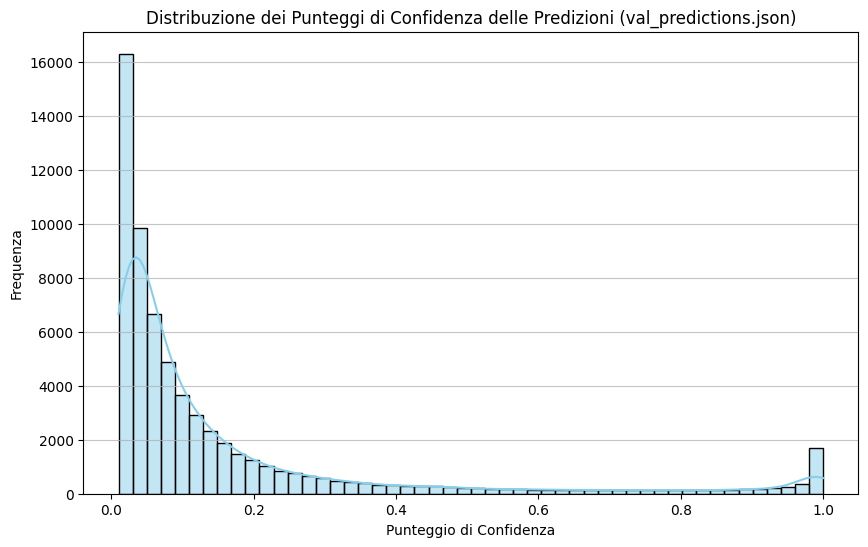


Statistiche Descrittive dei Punteggi di Confidenza per val_predictions.json:
count    63863.000000
mean         0.159404
std          0.233171
min          0.010001
25%          0.029253
50%          0.066319
75%          0.162379
max          0.999737
dtype: float64


In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_confidence_distribution(preds_file_path):
    """
    Analizza e visualizza la distribuzione dei punteggi di confidenza da un file JSON di predizioni.

    Args:
        preds_file_path (str): Il percorso del file JSON contenente le predizioni.
    """
    # Carica il file JSON con le predizioni
    try:
        with open(preds_file_path, 'r') as f:
            predictions_data = json.load(f)
    except FileNotFoundError:
        print(f"Errore: Il file di predizioni '{preds_file_path}' non è stato trovato.")
        return
    except json.JSONDecodeError:
        print(f"Errore: Impossibile decodificare il JSON da '{preds_file_path}'. Il file potrebbe essere corrotto o vuoto.")
        return

    if not predictions_data:
        print(f"Nessuna predizione trovata nel file '{preds_file_path}'. Impossibile analizzare.")
        return

    # Estrai i punteggi di confidenza
    scores = [pred['score'] for pred in predictions_data if 'score' in pred]

    if not scores:
        print(f"Nessun punteggio di confidenza trovato nelle predizioni di '{preds_file_path}'. Impossibile analizzare.")
        return

    # Converti in una Series Pandas per una facile analisi
    scores_series = pd.Series(scores)

    # Visualizza la distribuzione dei punteggi
    plt.figure(figsize=(10, 6))
    sns.histplot(scores_series, bins=50, kde=True, color='skyblue')
    plt.title(f'Distribuzione dei Punteggi di Confidenza delle Predizioni ({os.path.basename(preds_file_path)})')
    plt.xlabel('Punteggio di Confidenza')
    plt.ylabel('Frequenza')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Mostra alcune statistiche descrittive
    print(f'\nStatistiche Descrittive dei Punteggi di Confidenza per {os.path.basename(preds_file_path)}:')
    print(scores_series.describe())

# Esegui la funzione con il file di predizioni corrente
current_preds_file = 'val_predictions.json'
analyze_confidence_distribution(current_preds_file)

# Fine-tuning e risultati

In [10]:
# Esegue il comando di training definito in precedenza.
# Assicurati di avere una GPU disponibile e memoria sufficiente.
# Potresti voler modificare i parametri --batch_size e --epochs nella cella YbCig6TNyDBV
# prima di eseguire per adattarli alle tue risorse.

# La variabile TRAIN_CMD è stata definita nella cella YbCig6TNyDBV
# La variabile OUTPUT_DIR è stata definita nella cella YbCig6TNyDBV
# os.system(TRAIN_CMD.format(out=OUTPUT_DIR))

256

In [10]:
import torch

print("CUDA disponibile:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"Memoria GPU: {props.total_memory / 1024**3:.1f} GB")

CUDA disponibile: True
GPU: Tesla T4
Memoria GPU: 14.6 GB


In [11]:
import json
from pathlib import Path

def inspect_coco_categories(json_path):
    json_path = Path(json_path)

    with json_path.open("r") as f:
        coco = json.load(f)

    categories = coco["categories"]

    print(f"File: {json_path}")
    print("Categorie:")
    for category in categories:
        print(f"  id={category['id']}, name={category['name']}")

    print("Numero categorie:", len(categories))
    print("Numero immagini:", len(coco["images"]))
    print("Numero annotazioni:", len(coco["annotations"]))

    category_ids = sorted(category["id"] for category in categories)
    print("Category IDs:", category_ids)

    return categories


train_categories = inspect_coco_categories(
    "/content/hardhat_coco/annotations/instances_train2017.json"
)

val_categories = inspect_coco_categories(
    "/content/hardhat_coco/annotations/instances_val2017.json"
)

File: /content/hardhat_coco/annotations/instances_train2017.json
Categorie:
  id=1, name=Helmet
  id=2, name=Person
  id=3, name=Head
Numero categorie: 3
Numero immagini: 4250
Numero annotazioni: 21569
Category IDs: [1, 2, 3]
File: /content/hardhat_coco/annotations/instances_val2017.json
Categorie:
  id=1, name=Helmet
  id=2, name=Person
  id=3, name=Head
Numero categorie: 3
Numero immagini: 750
Numero annotazioni: 3933
Category IDs: [1, 2, 3]


In [13]:
!python detr/main.py \
  --coco_path hardhat_coco \
  --dataset_file coco \
  --batch_size 4 \
  --num_workers 2 \
  --lr 1e-4 \
  --lr_backbone 0 \
  --epochs 4 \
  --device cuda \
  --resume detr/detr-r50-e632da11.pth \
  --output_dir output_hardhat

Not using distributed mode
git:
  sha: 29901c51d7fe8712168b8d0d64351170bc0f83e0, status: clean, branch: HEAD

Namespace(lr=0.0001, lr_backbone=0.0, batch_size=4, weight_decay=0.0001, epochs=4, lr_drop=200, clip_max_norm=0.1, frozen_weights=None, backbone='resnet50', dilation=False, position_embedding='sine', enc_layers=6, dec_layers=6, dim_feedforward=2048, hidden_dim=256, dropout=0.1, nheads=8, num_queries=100, pre_norm=False, masks=False, aux_loss=True, set_cost_class=1, set_cost_bbox=5, set_cost_giou=2, mask_loss_coef=1, dice_loss_coef=1, bbox_loss_coef=5, giou_loss_coef=2, eos_coef=0.1, dataset_file='coco', coco_path='hardhat_coco', coco_panoptic_path=None, remove_difficult=False, output_dir='output_hardhat', device='cuda', seed=42, resume='detr/detr-r50-e632da11.pth', start_epoch=0, eval=False, num_workers=2, world_size=1, dist_url='env://', distributed=False)
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is depre

In [14]:
import os

# Elenca i contenuti della directory di output per verificare i file generati dal training
print(f"Contenuto di '{OUTPUT_DIR}':")
!ls -lh {OUTPUT_DIR}

Contenuto di 'output_hardhat':
total 298M
-rw-r--r-- 1 root root 297M Sep 16 21:10 checkpoint.pth
drwxr-xr-x 2 root root 4.0K Sep 16 20:49 eval
-rw-r--r-- 1 root root  18K Sep 16 21:11 log.txt


Trovato l'ultimo checkpoint fine-tunato: output_hardhat/checkpoint.pth


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Analizzando le predizioni da: val_predictions_ft.json
Generazione del file di predizioni...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


inference val: 100%|██████████| 750/750 [00:27<00:00, 27.66it/s]


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.53s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=4.57s).
Accumulating evaluation results...
DONE (t=0.52s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.084
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.283
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.025
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.030
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.163
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.334
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.070
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.249
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

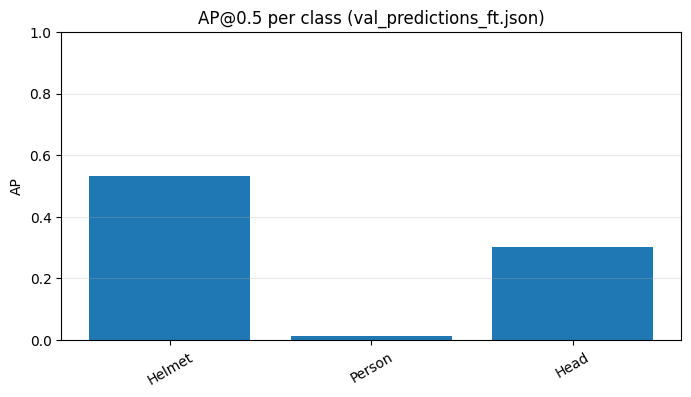

mAP@.5 (from COCOeval): 0.28285561457782904


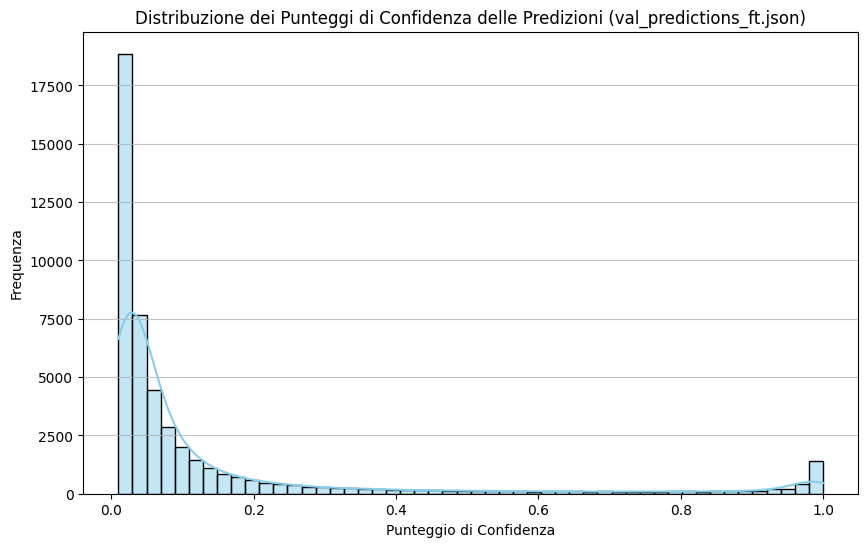


Statistiche Descrittive dei Punteggi di Confidenza per val_predictions_ft.json:
count    48480.000000
mean         0.141529
std          0.242171
min          0.010000
25%          0.020040
50%          0.042335
75%          0.115127
max          0.999558
dtype: float64


In [17]:
import os, glob, argparse, torch

# Cerca il checkpoint più recente nella directory di output del fine-tuning
# (Assumiamo che il fine-tuning sia terminato o abbia prodotto almeno un checkpoint)

# Autorizza la classe argparse.Namespace per il caricamento sicuro
torch.serialization.add_safe_globals([argparse.Namespace])

# La variabile OUTPUT_DIR è stata definita nella cella YbCig6TNyDBV
fine_tuned_ckpt_candidates = sorted(glob.glob(OUTPUT_DIR + '/checkpoint*.pth') + glob.glob(OUTPUT_DIR + '/checkpoint.pth'))

if not fine_tuned_ckpt_candidates:
    print(f"ATTENZIONE: Nessun checkpoint trovato in '{OUTPUT_DIR}'. Il training potrebbe essere ancora in corso o non è riuscito a generare checkpoint.")
    print("Per favore, verifica lo stato del training nella cella SvY7i6pXs4lG e riprova più tardi.")
else:
    # Usa il checkpoint più recente
    fine_tuned_ckpt_path = fine_tuned_ckpt_candidates[-1]
    print(f"Trovato l'ultimo checkpoint fine-tunato: {fine_tuned_ckpt_path}")

    # Ricarica il modello con il checkpoint fine-tunato
    # Le variabili 'device' e 'build_and_load_model_from_ckpt' sono definite nella cella oPmBxdG-yDBV
    model_ft, postprocessors_instance_ft = build_and_load_model_from_ckpt(fine_tuned_ckpt_path, device=device)

    # Esegui la valutazione e salva le predizioni nel file richiesto
    fine_tuned_preds_file = 'val_predictions_ft.json'
    evaluate_predictions_and_plot_map(
        fine_tuned_preds_file,
        model_ft,
        postprocessors_instance_ft,
        device
    )

    # Per completezza, puoi anche analizzare la distribuzione dei punteggi di confidenza del modello fine-tunato
    # la funzione analyze_confidence_distribution è definita nella cella 2b83e1a5
    analyze_confidence_distribution(fine_tuned_preds_file)


Score massimo tra tutte le 100 query: 0.999
Top 5 query per score:
  query 21: label=1 score=0.999
  query 11: label=1 score=0.996
  query 25: label=1 score=0.993
  query 53: label=1 score=0.967
  query 37: label=1 score=0.964


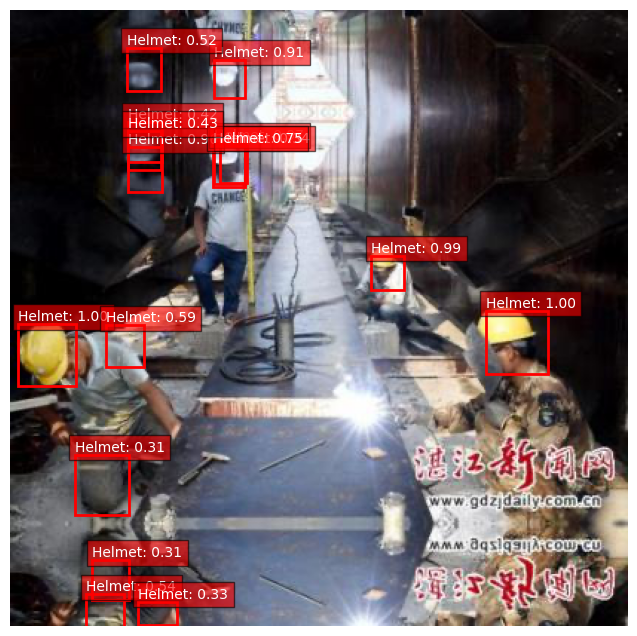

In [24]:
# @title
# pick a val image
val_images = sorted(glob.glob('hardhat_coco/val2017/*'))
if not val_images:
    print('No val images found in hardhat_coco/val2017')
else:
    img_path = val_images[2]
    img = Image.open(img_path).convert('RGB')
    inp = preprocess_pil(img).to(device)

    with torch.no_grad():
        out = model_ft([inp])  # ok per il modello ufficiale: accetta una lista di tensori (C,H,W)

    # --- estrazione corretta di boxes/scores/labels da pred_logits + pred_boxes ---
    pred_logits = out['pred_logits'][0]  # (num_queries, num_classes+1) — tolta la dim di batch
    pred_boxes  = out['pred_boxes'][0]   # (num_queries, 4), formato cx,cy,w,h normalizzato in [0,1]

    # softmax su tutte le classi tranne l'ultima, che è la classe "no object"
    # (stessa convenzione usata nella demo ufficiale: probas = pred_logits.softmax(-1)[..., :-1])
    probas = pred_logits.softmax(-1)[:, :-1]
    scores, labels = probas.max(-1)

    scores = scores.cpu().numpy()
    labels = labels.cpu().numpy()
    boxes  = pred_boxes.cpu().numpy()

    # utile per debug: guarda lo score massimo assoluto, a prescindere dalla soglia
    print(f"Score massimo tra tutte le {len(scores)} query: {scores.max():.3f}")
    print("Top 5 query per score:")
    top5 = scores.argsort()[::-1][:5]
    for i in top5:
        print(f"  query {i}: label={labels[i]} score={scores[i]:.3f}")

    # conversione cx,cy,w,h -> x0,y0,x1,y1 in pixel
    w, h = img.size
    cx, cy, bw, bh = boxes[:, 0]*w, boxes[:, 1]*h, boxes[:, 2]*w, boxes[:, 3]*h
    boxes_xyxy = np.stack([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2], axis=1)

    class_names = {1: 'Helmet', 2: 'Person', 3: 'Head'}
    visualize_preds(img_path, boxes_xyxy, labels, scores, class_names, score_thr=0.3)

Checkpoint 'detr/detr-r50-e632da11.pth' non contiene 'args'. Uso i default di DETR.
Checkpoint fine-tunato: output_hardhat/checkpoint.pth


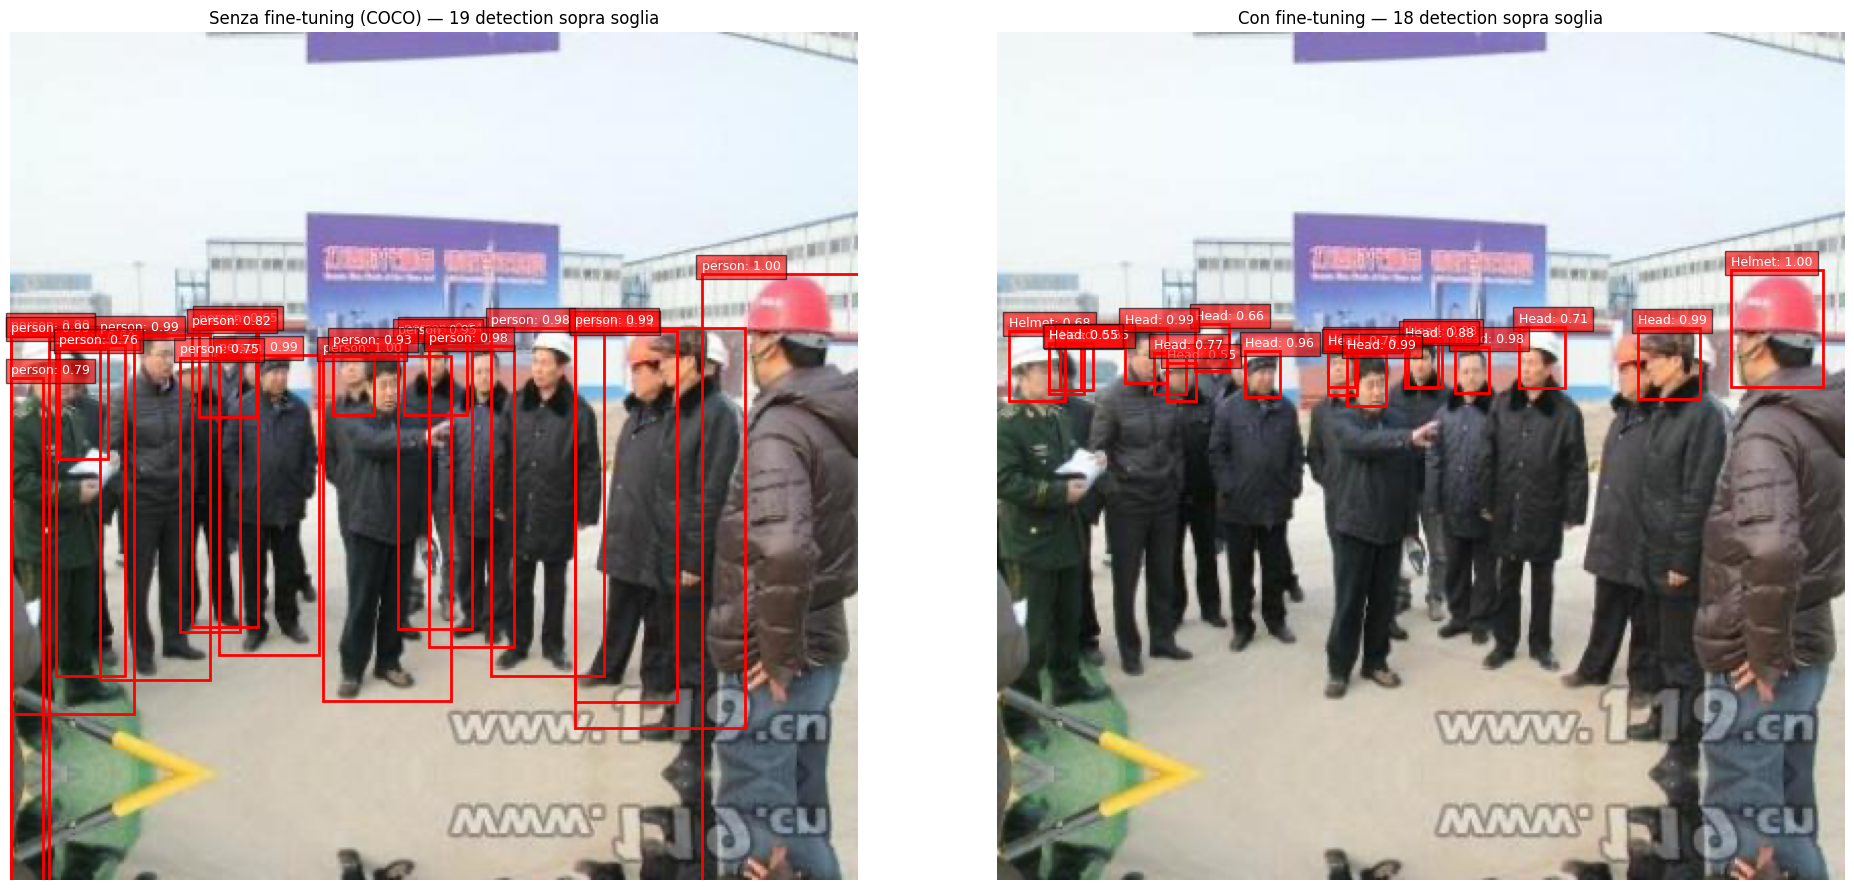

In [29]:
# @title
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# classi COCO originali (91), per il modello NON fine-tunato
COCO_CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]
CLASSES_PRETRAINED = {i: name for i, name in enumerate(COCO_CLASSES)}
CLASSES_FT = {1: 'Helmet', 2: 'Person', 3: 'Head'}


def run_inference(model, postprocessors, img, transform, device):
    """Inferenza + postprocessing ufficiale (softmax, no-object, rescale su img originale)."""
    orig_w, orig_h = img.size
    inp = transform(img).to(device)
    with torch.no_grad():
        out = model([inp])
    target_sizes = torch.tensor([[orig_h, orig_w]], device=device)
    results = postprocessors['bbox'](out, target_sizes)[0]
    return (results['boxes'].cpu().numpy(),
            results['scores'].cpu().numpy(),
            results['labels'].cpu().numpy())


def draw_preds(ax, img, boxes, labels, scores, class_names, score_thr, title):
    ax.imshow(img)
    n_shown = 0
    for b, l, s in zip(boxes, labels, scores):
        if s < score_thr:
            continue
        n_shown += 1
        x1, y1, x2, y2 = b
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor='red', linewidth=2))
        ax.text(x1, max(y1 - 2, 0), f"{class_names.get(int(l), '?')}: {s:.2f}",
                color='white', fontsize=9, bbox=dict(facecolor='red', alpha=0.6))
    ax.set_title(f"{title} — {n_shown} detection sopra soglia")
    ax.axis('off')


def compare_models(img_path, model_a, postproc_a, classes_a, title_a,
                    model_b, postproc_b, classes_b, title_b,
                    transform, device, score_thr=0.5):
    img = Image.open(img_path).convert('RGB')

    boxes_a, scores_a, labels_a = run_inference(model_a, postproc_a, img, transform, device)
    boxes_b, scores_b, labels_b = run_inference(model_b, postproc_b, img, transform, device)

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    draw_preds(axes[0], img, boxes_a, labels_a, scores_a, classes_a, score_thr, title_a)
    draw_preds(axes[1], img, boxes_b, labels_b, scores_b, classes_b, score_thr, title_b)
    plt.tight_layout()
    plt.show()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- modello SENZA fine-tuning: pesi ufficiali COCO ---
ckpt_path_base = 'detr/detr-r50-e632da11.pth'
model, postprocessors = build_and_load_model_from_ckpt(ckpt_path_base, device=device)

# --- modello CON fine-tuning: ultimo checkpoint salvato in OUTPUT_DIR ---
ft_candidates = sorted(glob.glob(OUTPUT_DIR + '/checkpoint*.pth') + glob.glob(OUTPUT_DIR + '/checkpoint.pth'))
if not ft_candidates:
    raise FileNotFoundError(f"Nessun checkpoint fine-tunato trovato in '{OUTPUT_DIR}'")
ckpt_path_ft = ft_candidates[-1]
print('Checkpoint fine-tunato:', ckpt_path_ft)

model_ft, postprocessors_ft = build_and_load_model_from_ckpt(ckpt_path_ft, device=device)

# uso: model/postprocessors = pretrained COCO, model_ft/postprocessors_ft = fine-tunato
compare_models(
    img_path=val_images[0],
    model_a=model, postproc_a=postprocessors, classes_a=CLASSES_PRETRAINED, title_a='Senza fine-tuning (COCO)',
    model_b=model_ft, postproc_b=postprocessors_ft, classes_b=CLASSES_FT, title_b='Con fine-tuning',
    transform=transform, device=device, score_thr=0.5,
)

In [30]:
import json
from collections import Counter

def class_distribution(ann_path):
    with open(ann_path) as f:
        data = json.load(f)
    cat_id_to_name = {c['id']: c['name'] for c in data['categories']}
    counts = Counter(ann['category_id'] for ann in data['annotations'])
    print(f"--- {ann_path} ---")
    for cat_id, name in cat_id_to_name.items():
        print(f"  {name} (id={cat_id}): {counts.get(cat_id, 0)} istanze")

    # controllo box degeneri: width o height <= 0
    bad_boxes = [a for a in data['annotations'] if a['bbox'][2] <= 0 or a['bbox'][3] <= 0]
    if bad_boxes:
        print(f"  ⚠️ {len(bad_boxes)} box con width/height <= 0")

class_distribution('hardhat_coco/annotations/instances_train2017.json')
class_distribution('hardhat_coco/annotations/instances_val2017.json')

--- hardhat_coco/annotations/instances_train2017.json ---
  Helmet (id=1): 16021 istanze
  Person (id=2): 658 istanze
  Head (id=3): 4890 istanze
--- hardhat_coco/annotations/instances_val2017.json ---
  Helmet (id=1): 2945 istanze
  Person (id=2): 93 istanze
  Head (id=3): 895 istanze
